In [1]:
import os
api_key = os.environ.get("AGICTO_API_KEY", "sk-h9d8tMxaLmuysdwUAtgewbvtpTfjCVZKPTYDl6GrBpPm4QgV")

In [4]:
import torch
from openai import OpenAI
client = OpenAI(
 api_key="sk-h9d8tMxaLmuysdwUAtgewbvtpTfjCVZKPTYDl6GrBpPm4QgV",
 base_url="https://api.agicto.cn/v1"
)
print("环境配置完成！")

环境配置完成！


In [5]:
import os
from openai import OpenAI
# 配置 agicto API
client = OpenAI(
 api_key=os.environ.get("AGICTO_API_KEY", "sk-h9d8tMxaLmuysdwUAtgewbvtpTfjCVZKPTYDl6GrBpPm4QgV"),
 base_url="https://api.agicto.cn/v1"
)
MODEL = "gpt-4o-mini" 

In [7]:
def chat_with_llm(messages, model=MODEL, temperature=0.7, max_tokens=1024):
 """发送消息给 LLM 并获取回复"""
 response = client.chat.completions.create(
 model=model,
 messages=messages,
 temperature=temperature,
 max_tokens=max_tokens
 )
 return response.choices[0].message.content
# 基础测试
messages = [{"role": "user", "content": "你好，请简单介绍下番茄的种植要点。"}]
reply = chat_with_llm(messages)
print(reply)

你好！番茄的种植要点包括以下几个方面：

1. **选址**：番茄喜欢阳光充足的环境，选择一个每天可以接受至少6-8小时直射阳光的地方。

2. **土壤**：番茄适合生长在排水良好、富含有机质的土壤中。土壤的pH值应在6.0到6.8之间。

3. **播种与移栽**：
   - **播种**：可以选择在温暖的春季进行室内播种，待幼苗长出2-3片真叶后进行移栽。
   - **移栽**：在气温稳定在15℃以上时，将幼苗移植到户外。

4. **浇水**：保持土壤湿润，特别是在开花和结果期间，避免土壤过于干燥或积水。

5. **施肥**：在生长初期可以施用氮肥，开花期和结果期则需要增加磷钾肥的施用，以促进花果的形成。

6. **支撑**：番茄植物生长较高，建议使用支架或绳索进行支撑，以防止倒伏。

7. **病虫害防治**：定期检查植物，注意防治常见的病虫害，如蚜虫、白粉病等，可以采用生物或化学防治方法。

8. **收获**：番茄成熟时颜色鲜艳，手感稍软，即可采摘。

希望这些要点能帮助你成功种植番茄！


In [11]:
import time

def benchmark_prompt(system_prompt, user_prompt, label=""):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    start = time.time()
    reply = chat_with_llm(messages, temperature=0.3)
    elapsed = time.time() - start
    print(f"\n{'='*60}")
    print(f"【{label}】")
    print(f"耗时: {elapsed:.1f}s")
    print(f"回答:\n{reply}")
    return reply

# ── 实验 1：基础 prompt（无角色设定） ──
benchmark_prompt(
    system_prompt="",
    user_prompt="番茄叶子发黄是什么原因？",
    label="实验1：基础Prompt"
)

# ── 实验 2：角色设定 + 结构化要求 ──
benchmark_prompt(
    system_prompt="""你是一位有20年经验的农业植保专家。请用专业但易懂的语言回答农民的病害
问题。""",
    user_prompt="""番茄叶子发黄是什么原因？请从以下方面分析：1. 可能的病害类型 2. 非病害原
因（营养、水分等）3. 如何区分 4. 防治建议""",
    label="实验2：角色设定+结构化"
)

# ── 实验 3：Few-shot + Chain of Thought ──
benchmark_prompt(
    system_prompt="""你是一位农业植保专家。请按以下步骤分析：先观察症状特征，再对比已知病
害，最后给出诊断和建议。""",
    user_prompt="""请参考以下诊断示例，对新的症状进行分析：
示例1：
- 症状：番茄叶片出现同心轮纹状褐色病斑
- 诊断：早疫病（Alternaria solani）。轮纹状病斑是典型特征。
- 建议：移除病叶，喷施代森锰锌或苯醚甲环唑。
示例2：
- 症状：番茄果实出现水渍状褐色凹陷斑，高湿环境下有白色霉层
- 诊断：晚疫病（Phytophthora infestans）。水渍状斑和白色霉层是关键特征。
- 建议：控制湿度，喷施烯酰吗啉或霜脲氰。
新症状：番茄叶片边缘出现 V 形黄褐色坏死斑，病健交界明显，多从下部叶片开始。
请逐步分析。""",
    label="实验3：Few-shot+逐步推理"
)


【实验1：基础Prompt】
耗时: 5.2s
回答:
番茄叶子发黄可能有多种原因，以下是一些常见的因素：

1. **水分问题**：
   - **过浇水**：土壤长期湿润会导致根部缺氧，进而引起根腐病，导致叶子发黄。
   - **缺水**：如果土壤过于干燥，植物也会因为缺水而出现叶子发黄的现象。

2. **营养缺乏**：
   - **氮缺乏**：氮是植物生长的重要元素，缺乏时叶子通常会变黄，尤其是老叶。
   - **其他营养元素缺乏**：如铁、镁、锌等微量元素缺乏，也会导致叶子发黄。

3. **病虫害**：
   - 某些病虫害（如白粉病、蚜虫等）会影响植物的健康，导致叶子变黄。

4. **光照不足**：
   - 番茄需要充足的阳光，如果光照不足，叶子可能会发黄。

5. **温度问题**：
   - 番茄对温度比较敏感，过高或过低的温度都可能导致叶子发黄。

6. **土壤问题**：
   - 土壤的酸碱度不适合（如过酸或过碱）也可能影响植物的营养吸收，导致叶子发黄。

针对这些问题，可以通过调整浇水频率、施肥、检查病虫害、改善光照条件等方式来解决。

【实验2：角色设定+结构化】
耗时: 6.8s
回答:
番茄叶子发黄是一个常见的问题，可能由多种因素引起。我们可以从以下几个方面进行分析：

### 1. 可能的病害类型
- **真菌性病害**：如灰霉病、白粉病等，这些病害通常会导致叶片出现斑点或霉斑，最终导致叶片变黄。
- **细菌性病害**：如细菌性叶斑病，叶片上会出现水浸状斑点，随着病情加重，叶片会变黄并枯萎。
- **病毒性病害**：如番茄黄化曲叶病毒，感染后叶片会出现变黄、卷曲等现象。

### 2. 非病害原因
- **营养缺乏**：缺乏氮、铁、镁等元素会导致叶片发黄。氮缺乏通常表现为老叶发黄，而铁缺乏则多见于新叶。
- **水分问题**：过多或过少的水分都可能导致根系受损，进而影响植物的营养吸收，导致叶片发黄。
- **土壤pH值不适**：土壤酸碱度不适宜会影响养分的有效性，导致植物无法吸收所需的营养。

### 3. 如何区分
- **观察症状**：病害通常伴随特定的症状，如斑点、霉斑等，而营养缺乏则通常表现为整体的黄化。
- **检查叶片**：用手轻轻擦拭叶片，若有霉斑或虫害，可能是病害；若叶片表面光滑且均匀发黄，可能是营养缺

'- 症状：番茄叶片边缘出现 V 形黄褐色坏死斑，病健交界明显，多从下部叶片开始。\n\n- 诊断：该症状符合番茄的细菌性叶斑病（Xanthomonas campestris pv. vesicatoria）。V 形黄褐色坏死斑是该病的典型特征，且病健交界明显，通常从下部叶片开始蔓延。\n\n- 建议：及时移除病叶，避免病害扩散。可以喷施铜制剂（如氧化亚铜）或其他有效的细菌性病害防治药剂。同时，注意田间管理，保持良好的通风和适当的灌溉，减少湿度，以降低病害发生的风险。'

In [13]:
# 模拟一次完整的农业咨询对话
messages = [
    {"role": "system", "content": """你是农业植保专家，专门帮助农民诊断和防治作物病害。
回答要专业、实用、有依据。"""}
]

def multi_turn_chat(user_input):
    messages.append({"role": "user", "content": user_input})
    reply = chat_with_llm(messages, temperature=0.5)
    messages.append({"role": "assistant", "content": reply})
    print(f"你: {user_input}")
    print(f"专家: {reply}\n")
    return reply

# 多轮对话测试
multi_turn_chat("我家的番茄最近叶子开始出现褐色斑点，集中在下部叶片，是怎么回事？")
multi_turn_chat("用什么药比较好？我现在手头有代森锰锌。")
multi_turn_chat("打药的频率应该是多少？")

你: 我家的番茄最近叶子开始出现褐色斑点，集中在下部叶片，是怎么回事？
专家: 番茄叶片出现褐色斑点，特别是集中在下部叶片，可能是几种病害或环境因素引起的。以下是一些常见的原因及其防治措施：

1. **真菌性病害**：
   - **番茄叶霉病**（如早疫病）：通常表现为叶片上出现褐色斑点，斑点周围有黄色晕圈，病害从下部叶片开始扩展。
   - **防治措施**：
     - 清除病残体，保持田间卫生。
     - 适当轮作，避免在同一块地连续种植番茄。
     - 使用抗病品种。
     - 在发病初期喷施适当的杀菌剂，如多菌灵、甲基托布津等。

2. **细菌性病害**：
   - **细菌性叶斑病**：表现为叶片上出现水浸状的褐色斑点，通常边缘不规则。
   - **防治措施**：
     - 清除病叶，减少细菌传播。
     - 避免叶面潮湿，适时浇水，保持通风良好。
     - 使用细菌性病害专用的药剂进行防治，如铜制剂。

3. **营养缺乏**：
   - **缺钙或缺镁**：缺钙时，植物可能表现为叶尖和边缘褐色，缺镁时则可能出现叶片黄化和褐色斑点。
   - **防治措施**：
     - 进行土壤检测，了解土壤养分状况。
     - 根据土壤检测结果，适量施用钙肥或镁肥。

4. **环境因素**：
   - **水分管理不当**：过多或过少的水分都可能导致根系受损，从而影响叶片健康。
   - **防治措施**：
     - 确保土壤排水良好，避免积水。
     - 根据天气和土壤湿度调整浇水频率。

建议您仔细观察病害的具体表现，并结合当地的气候条件和管理方式，选择合适的防治措施。如果情况严重，建议咨询当地的农业专家或植保服务机构，进行更详细的诊断和处理。

你: 用什么药比较好？我现在手头有代森锰锌。
专家: 代森锰锌是一种常用的广谱杀菌剂，主要用于防治真菌性病害，尤其对叶霉病、白粉病等有较好的效果。针对您提到的番茄叶片出现褐色斑点的情况，代森锰锌可以作为一种选择，尤其是如果怀疑是由真菌引起的病害。

### 使用代森锰锌的建议：

1. **稀释比例**：根据产品说明书，通常代森锰锌的稀释比例为每1000升水中加入适量的代森锰锌（例如，0.5-1公斤），具体请参考产品标签。

2. **喷施时间**：建议在早晨或傍晚

'打药的频率通常取决于多种因素，包括病害的严重程度、天气条件、作物生长阶段以及所使用药剂的特点。以下是一些一般性建议：\n\n1. **初期防治**：如果发现病害初期，建议每7-10天喷施一次药剂。这段时间内，病害可能发展较快，因此需要较频繁的防治。\n\n2. **病害严重时**：如果病害已经较为严重，可以考虑每5-7天喷施一次，以便更及时地控制病害扩散。\n\n3. **病害控制后**：当病害得到有效控制后，可以适当延长喷药间隔，通常为10-14天一次。此时要保持对病害的监测，确保没有复发。\n\n4. **季节和气候影响**：在潮湿、阴雨天气条件下，病害发展较快，可能需要缩短喷药间隔；而在干燥、晴朗的天气条件下，可以适当延长喷药间隔。\n\n5. **药剂交替使用**：为了防止病原菌产生抗药性，建议在使用代森锰锌时，可以与其他类型的杀菌剂交替使用，交替使用的药剂喷施间隔也应遵循相似的原则。\n\n### 总结\n- **初期防治**：每7-10天喷施一次。\n- **病害严重时**：每5-7天喷施一次。\n- **病害控制后**：每10-14天喷施一次。\n\n在实际操作中，建议根据具体的病害情况和天气条件进行灵活调整，并保持对作物状况的监测，以便及时采取措施。'

尝试下载: https://raw.githubusercontent.com/googlefonts/noto-cjk/main/...


/tmp/ipykernel_191/1410060565.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(experiments, fontproperties=font_prop)
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei


字体下载成功
字体已加载: NotoSansCJKsc-Regular.otf


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

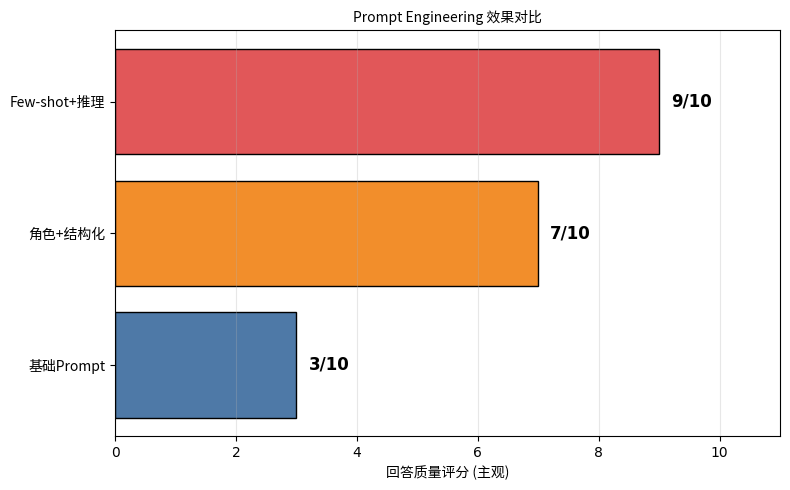

In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import urllib.request
import requests

# ── 多源下载 + 系统字体兜底 ──
font_path = "NotoSansCJKsc-Regular.otf"

# 候选下载地址（按可靠性排序）
urls = [
    "https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf",
    "https://cdn.jsdelivr.net/gh/googlefonts/noto-cjk/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf",
]

def download_font(path, url_list):
    for url in url_list:
        try:
            print(f"尝试下载: {url[:60]}...")
            # 用 requests 并加超时，避免卡住
            r = requests.get(url, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
            if r.status_code == 200:
                with open(path, "wb") as f:
                    f.write(r.content)
                print("字体下载成功")
                return True
        except Exception as e:
            print(f"  失败: {e}")
    return False

# 1. 先尝试下载
if not os.path.exists(font_path):
    if not download_font(font_path, urls):
        print("\n⚠️ 下载全部失败，尝试查找系统自带字体...")

# 2. 如果下载失败，扫描系统字体
if not os.path.exists(font_path):
    system_candidates = []
    for font in fm.fontManager.ttflist:
        name = font.name.lower()
        if any(k in name for k in ['cjk', 'noto', 'wqy', 'wenquanyi', 'droid', 'source han']):
            system_candidates.append(font.fname)
    
    if system_candidates:
        font_path = system_candidates[0]
        print(f"使用系统字体: {font_path}")
    else:
        print("⚠️ 未找到任何中文字体，图表将使用英文标签")
        font_path = None

# ── 注册并绘图 ──
if font_path and os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_prop = fm.FontProperties(fname=font_path)
    print(f"字体已加载: {font_path}")
else:
    font_prop = None

experiments = ["基础Prompt", "角色+结构化", "Few-shot+推理"]
quality_scores = [3, 7, 9]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(experiments, quality_scores, color=["#4e79a7", "#f28e2b", "#e15759"], edgecolor="black")

for bar, score in zip(bars, quality_scores):
    ax.text(score + 0.2, bar.get_y() + bar.get_height()/2,
            f"{score}/10", va="center", fontsize=12, fontweight="bold")

# 绑定字体
if font_prop:
    ax.set_xlabel("回答质量评分 (主观)", fontproperties=font_prop)
    ax.set_title("Prompt Engineering 效果对比", fontproperties=font_prop)
    ax.set_yticklabels(experiments, fontproperties=font_prop)
else:
    ax.set_xlabel("Quality Score")
    ax.set_title("Prompt Engineering Comparison")
    ax.set_yticklabels(["Basic", "Role+Structure", "Few-shot+CoT"])

ax.set_xlim(0, 11)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("task_a_prompt_comparison.png", dpi=150, bbox_inches="tight")
plt.show()